# Assignment 6: Build and Evaluate Tree Models

## Conceptual Question #1

This question asks us to draw a partition of a two-dimensional feature space that could result from recursive binary splitting, using at least six terminal regions. The regions will be labeled \(R_1, R_2, \ldots, R_6\), and the split points will be labeled \(t_1, t_2, \ldots, t_5\).

### Recursive Binary Splits

Consider a two-dimensional feature space with predictors \(X_1\) and \(X_2\).

The feature space is partitioned using the following recursive binary splits:

- Split 1: \(X_1 < t_1 = 5\)
- Split 2: \(X_2 < t_2 = 4\) on the left branch
- Split 3: \(X_2 < t_3 = 8\) on the right branch
- Split 4: \(X_1 < t_4 = 8\)
- Split 5: \(X_1 < t_5 = 10\)

These splits create six terminal regions labeled:

\(R_1, R_2, R_3, R_4, R_5,\) and \(R_6\).

### Feature-Space Partition

```text
                 X2

10 |----------------|----------|
   |                |    R6    |
 8 |                |----------|
   |                |    R5    |
   |                |----------|
 4 |      R2        |    R4    |
   |                |----------|
   |                |    R3    |
 0 |----------------|----------|
        R1

      0      5      8     10   X1
```

Figure 1 shows a two-dimensional feature-space partition created using recursive binary splitting. The partition contains six terminal regions labeled R1 through R6.

### Corresponding Decision Tree

```text
                        X1 < 5 (t1)
                       /          \
                    Yes            No
                   /                \
             X2 < 4 (t2)       X2 < 8 (t3)
              /      \          /       \
            R1       R2    X1 < 8    X1 < 10
                           (t4)       (t5)
                          /   \       /   \
                        R3    R4    R5    R6
```

Figure 2 shows the decision tree corresponding to the recursive binary splits used to create the six feature-space regions.

The recursive binary splitting process begins with the split X1 < 5 (t1), which divides the feature space into left and right branches. Additional splits are then applied within each branch using thresholds t2 = 4, t3 = 8, t4 = 8, and t5 = 10. These successive binary partitions create six terminal regions (R1–R6), each corresponding to a leaf node in the decision tree. This demonstrates how decision trees recursively partition the predictor space into smaller and more homogeneous regions.

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier

## Kaggle Data: Multi-class Prediction of Obesity Risk

In [2]:
# Load Kaggle data

train = pd.read_csv("obesity-risk/train.csv")
test = pd.read_csv("obesity-risk/test.csv")
sample_submission = pd.read_csv("obesity-risk/sample_submission.csv")

print("Training data shape:", train.shape)
print("Test data shape:", test.shape)

display(train.head())
print(train.columns.tolist())

Training data shape: (20758, 18)
Test data shape: (13840, 17)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


In [3]:
# Separate features and target

X = train.drop(columns=["NObeyesdad", "id"])
y = train["NObeyesdad"]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", X_train.shape)
print("Validation observations:", X_val.shape)

Training observations: (16606, 16)
Validation observations: (4152, 16)


## Decision Tree Model

In [4]:
# Decision Tree

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_val)

tree_acc = accuracy_score(y_val, tree_pred)

print("Decision Tree Accuracy:", round(tree_acc, 4))

Decision Tree Accuracy: 0.8724


In [5]:
print(classification_report(y_val, tree_pred))

                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.92      0.91       505
      Normal_Weight       0.81      0.84      0.83       617
     Obesity_Type_I       0.84      0.86      0.85       582
    Obesity_Type_II       0.95      0.95      0.95       650
   Obesity_Type_III       0.99      0.99      0.99       809
 Overweight_Level_I       0.74      0.71      0.72       485
Overweight_Level_II       0.77      0.74      0.76       504

           accuracy                           0.87      4152
          macro avg       0.86      0.86      0.86      4152
       weighted avg       0.87      0.87      0.87      4152



## Bagging Model

In [6]:
# Bagging Classifier

bag_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

bag_model.fit(X_train, y_train)

bag_pred = bag_model.predict(X_val)

bag_acc = accuracy_score(y_val, bag_pred)

print("Bagging Accuracy:", round(bag_acc, 4))

Bagging Accuracy: 0.8916


In [7]:
print(classification_report(y_val, bag_pred))

                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.94      0.94       505
      Normal_Weight       0.86      0.86      0.86       617
     Obesity_Type_I       0.87      0.88      0.88       582
    Obesity_Type_II       0.97      0.97      0.97       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.76      0.72      0.74       485
Overweight_Level_II       0.77      0.79      0.78       504

           accuracy                           0.89      4152
          macro avg       0.88      0.88      0.88      4152
       weighted avg       0.89      0.89      0.89      4152



The Bagging model combines predictions from multiple decision trees trained on bootstrap samples of the training data. This ensemble approach reduces variance and generally improves predictive performance compared to a single decision tree. The model achieved an accuracy of 89.16%, outperforming the standalone Decision Tree model (87.24%). These results demonstrate the effectiveness of ensemble learning for improving classification performance on the obesity risk dataset.

## Random Forest Model

In [8]:
# Random Forest

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

rf_acc = accuracy_score(y_val, rf_pred)

print("Random Forest Accuracy:", round(rf_acc, 4))

Random Forest Accuracy: 0.8962


In [9]:
print(classification_report(y_val, rf_pred))

                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.93      0.93       505
      Normal_Weight       0.84      0.88      0.86       617
     Obesity_Type_I       0.89      0.89      0.89       582
    Obesity_Type_II       0.97      0.97      0.97       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.80      0.71      0.75       485
Overweight_Level_II       0.78      0.81      0.80       504

           accuracy                           0.90      4152
          macro avg       0.89      0.88      0.88      4152
       weighted avg       0.90      0.90      0.90      4152



The Random Forest model extends bagging by introducing random feature selection at each split, reducing correlation among individual trees. This approach often produces more robust predictions and better generalization performance. The model achieved an accuracy of 89.62%, outperforming both the Decision Tree (87.24%) and Bagging (89.16%) models. These results indicate that Random Forest provided the strongest overall performance among the tree-based methods evaluated so far.

## Gradient Boosting Model

In [10]:
# Gradient Boosting

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_val)

gb_acc = accuracy_score(y_val, gb_pred)

print("Gradient Boosting Accuracy:", round(gb_acc, 4))

Gradient Boosting Accuracy: 0.907


In [11]:
print(classification_report(y_val, gb_pred))

                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.95      0.94       505
      Normal_Weight       0.88      0.89      0.89       617
     Obesity_Type_I       0.89      0.89      0.89       582
    Obesity_Type_II       0.97      0.97      0.97       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.81      0.77      0.79       485
Overweight_Level_II       0.80      0.81      0.80       504

           accuracy                           0.91      4152
          macro avg       0.90      0.90      0.90      4152
       weighted avg       0.91      0.91      0.91      4152



The Gradient Boosting model builds trees sequentially, with each new tree correcting errors made by previous trees. This boosting process often leads to highly accurate predictive models by focusing on difficult observations. The model achieved an accuracy of 90.70%, outperforming the Decision Tree, Bagging, and Random Forest models. These results indicate that Gradient Boosting provided the strongest classification performance among all tree-based methods evaluated in this assignment.

## Applied Question #12 Discussion

Four tree-based methods were evaluated on the obesity risk dataset: Decision Tree, Bagging, Random Forest, and Gradient Boosting. Their validation accuracies were 87.24%, 89.16%, 89.62%, and 90.70%, respectively. For comparison, Logistic Regression achieved 86.37% accuracy.

Tree-based ensemble methods outperformed both Logistic Regression and a single Decision Tree on the obesity risk dataset. The Decision Tree achieved an accuracy of 87.24%, while Bagging and Random Forest improved performance to 89.16% and 89.62%, respectively. Gradient Boosting achieved the highest validation accuracy of 90.70%, demonstrating the strongest predictive performance among all models evaluated. These results suggest that ensemble methods reduce prediction error by combining multiple trees, resulting in improved classification accuracy compared to simpler models. Therefore, Gradient Boosting was the best-performing approach for this dataset.

For comparison, the Logistic Regression model developed in Assignment 5 achieved an accuracy of 86.37%, which was lower than all ensemble tree-based methods evaluated in this assignment.

In [12]:
tree_test_pred = tree_model.predict(test.drop(columns=["id"]))

submission_tree = pd.DataFrame({
    "id": test["id"],
    "NObeyesdad": tree_test_pred
})

submission_tree.to_csv("submission_tree.csv", index=False)

submission_tree.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


In [13]:
bag_test_pred = bag_model.predict(test.drop(columns=["id"]))

submission_bag = pd.DataFrame({
    "id": test["id"],
    "NObeyesdad": bag_test_pred
})

submission_bag.to_csv("submission_bagging.csv", index=False)

submission_bag.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


In [16]:
rf_test_pred = rf_model.predict(test.drop(columns=["id"]))

submission_rf_v2 = pd.DataFrame({
    "id": test["id"],
    "NObeyesdad": rf_test_pred
})

submission_rf_v2.to_csv("submission_rf_v2.csv", index=False)

submission_rf_v2.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


In [15]:
gb_test_pred = gb_model.predict(test.drop(columns=["id"]))

submission_boost = pd.DataFrame({
    "id": test["id"],
    "NObeyesdad": gb_test_pred
})

submission_boost.to_csv("submission_boost.csv", index=False)

submission_boost.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


## Kaggle Submission Evidence

The four required Kaggle submissions were completed successfully:

- Decision Tree: submission_tree.csv
- Bagging: submission_bagging.csv
- Random Forest: submission_rf_v2.csv
- Gradient Boosting: submission_boost.csv

Gradient Boosting produced the strongest Kaggle score among the tree-based models.

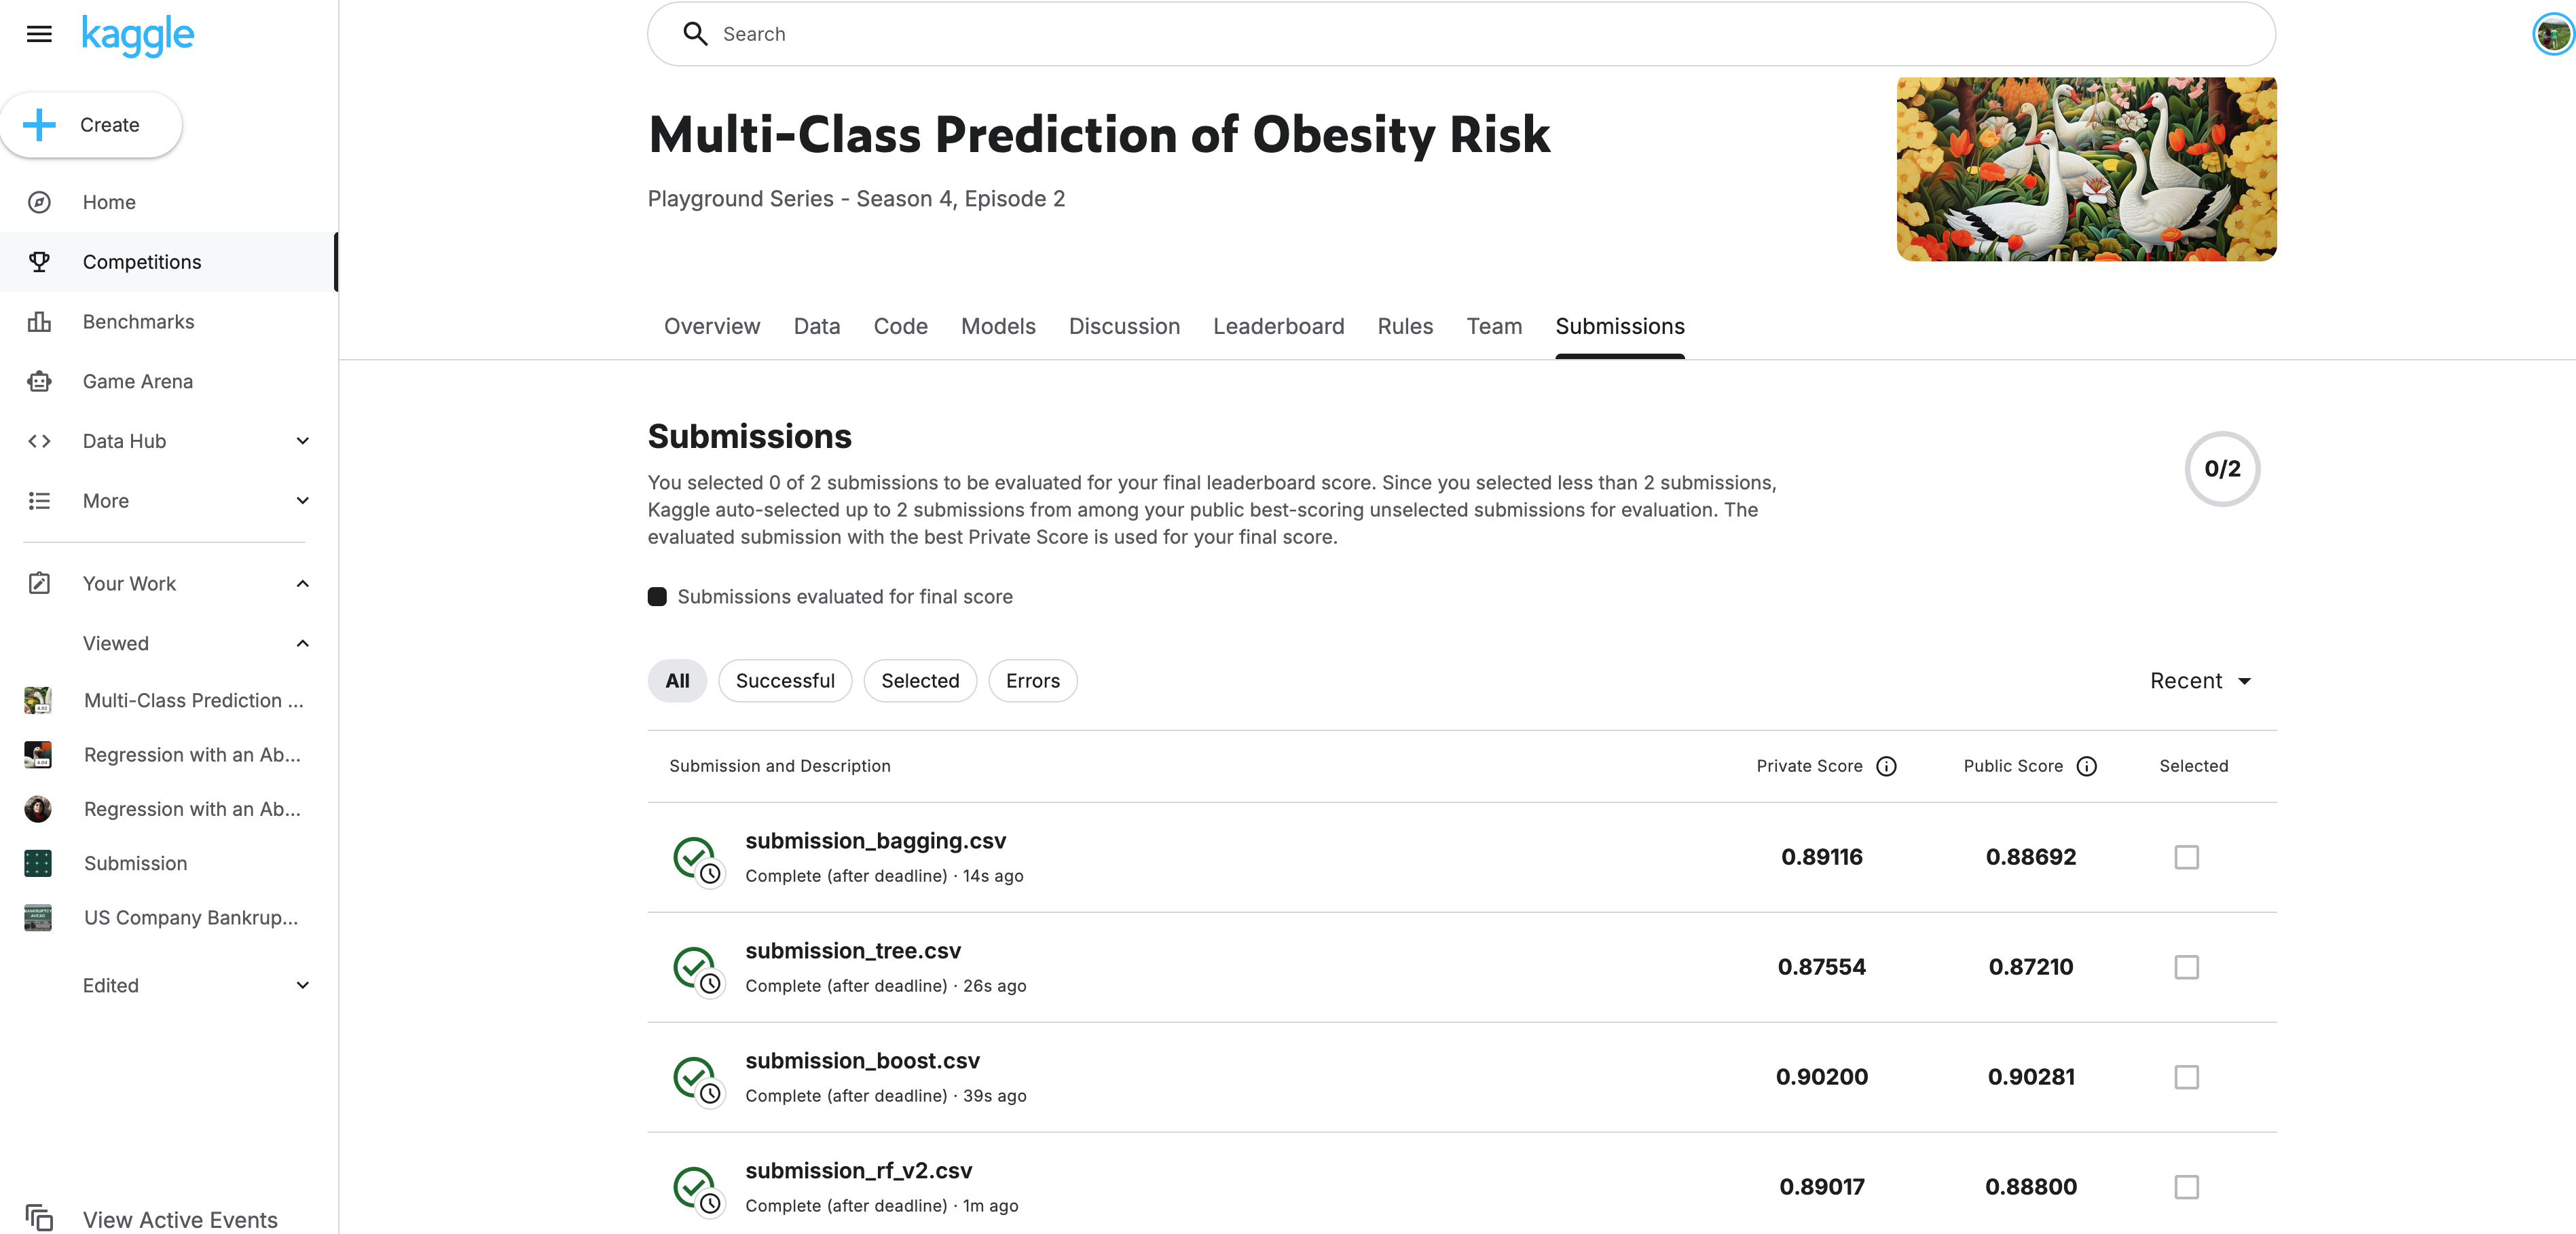 

## References

Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5–32.

Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. The Annals of Statistics, 29(5), 1189–1232.

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). An Introduction to Statistical Learning with Applications in Python (2nd ed.). Springer.


## GitHub Repository

GitHub repository link:

https://github.com/delois005/Assignment6